# Análise regional — acidentes na Dutra (Piraí → Guaratinguetá)

Recorte do Sul do Vale do Paraíba, o trecho que de fato interessa: 14 municípios
cortados pela Dutra, de **Piraí (RJ)** até **Guaratinguetá (SP)**.

**Fonte principal deste recorte: PRF** — ela tem `municipio`, `latitude`/`longitude`,
`causa_acidente`, `condicao_metereologica` e `uso_solo`, que a ANTT não tem.

Objetivo: diagnóstico de causas e padrões (causa, clima, horário, uso do solo,
veículo, gravidade).

## Microtarefa 0 — conectar ao banco e recortar a região

Aqui a gente só abre o banco e separa as linhas da nossa região num DataFrame
chamado `df_regiao`. Ele vira a base de todas as próximas análises.

In [114]:
# Bibliotecas que vamos usar
import sqlite3          # para conversar com o banco SQLite
import pandas as pd     # para trazer o resultado da query como tabela (DataFrame)

# Abre a conexão com o banco do projeto (mesmo caminho que você já usa no antt.ipynb)
conn = sqlite3.connect("/home/nathgobira/Documentos/Acidentes-Dutra/data/processed/acidentes.db")

# Os 14 municípios cortados pela Dutra no nosso recorte, na ordem da estrada (Rio -> SP).
MUNICIPIOS_REGIAO = [
    # Rio de Janeiro
    "PIRAI", "PINHEIRAL", "VOLTA REDONDA", "BARRA MANSA",
    "PORTO REAL", "RESENDE", "ITATIAIA",
    # São Paulo
    "QUELUZ", "LAVRINHAS", "CRUZEIRO", "CACHOEIRA PAULISTA",
    "CANAS", "LORENA", "GUARATINGUETA",
]

# Monta um "?" para cada município (jeito seguro de passar uma lista pro SELECT ... IN).
placeholders = ",".join(["?"] * len(MUNICIPIOS_REGIAO))
query = f"SELECT * FROM acidentes_prf WHERE municipio IN ({placeholders})"
df_regiao = pd.read_sql(query, conn, params=MUNICIPIOS_REGIAO)

# Remove a serra das Araras: a descida da Dutra em Piraí (km < 233). É uma dinâmica de
# serra (curvas, freio, tombamento), fora do foco do trabalho (trecho urbano/planalto).
# Decisão de 2026-09-18. O corte de 233 é aproximado e pode ser ajustado.
df_regiao["km"] = df_regiao["km"].astype(float)
serra = (df_regiao["municipio"] == "PIRAI") & (df_regiao["km"] < 233)
df_regiao = df_regiao[~serra]

print(f"Linhas no recorte regional: {len(df_regiao)}  (serra das Araras removida)")

Linhas no recorte regional: 6694


In [115]:
# --- Verificação ---
# 1) O total tem que bater com o que validamos no SQL. Com a série 2017-2026 e a serra
#    das Araras removida, o recorte tem 6.055 acidentes.
print("Total de acidentes na região:", len(df_regiao))

# 2) Quantos acidentes por município? Confere se aparecem só os 14 esperados
#    (nenhum município de fora, como GUARULHOS ou REGISTRO).
print("\nAcidentes por município:")
print(df_regiao["municipio"].value_counts())

# 3) Confere o período coberto (deve ir de 2017 a 2026).
print("\nPeríodo:", df_regiao["data_inversa"].min(), "a", df_regiao["data_inversa"].max())

Total de acidentes na região: 6694

Acidentes por município:
municipio
PIRAI                 1336
BARRA MANSA           1316
RESENDE                834
GUARATINGUETA          672
ITATIAIA               514
LORENA                 469
CACHOEIRA PAULISTA     318
LAVRINHAS              266
PORTO REAL             243
QUELUZ                 227
CANAS                  170
VOLTA REDONDA          155
CRUZEIRO               129
PINHEIRAL               45
Name: count, dtype: int64

Período: 2017-01-01 a 2026-07-31


## Microtarefa 1 — panorama: acidentes por ano (total, com e sem vítimas)

O retrato geral, com três linhas no mesmo gráfico:
- **Total** — todos os acidentes.
- **Com vítimas** — feridas ou fatais.
- **Sem vítimas** — só danos materiais.

A graça é justamente **ver a quebra de série**: a linha "sem vítimas" despenca ao
longo dos anos (a PRF passou a registrar cada vez menos), o que puxa o total pra
baixo artificialmente. A linha "com vítimas" é a que mostra o movimento real da
estrada — por isso ela é a nossa base de análise.

In [116]:
# Extrai o ano da data. 'data_inversa' vem como texto no formato 'AAAA-MM-DD',
# então os 4 primeiros caracteres (str[:4]) são o ano. .astype(int) transforma em número.
df_regiao["ano"] = df_regiao["data_inversa"].str[:4].astype(int)

# Marca cada acidente como COM vítima (True) ou SEM vítima (False).
tem_vitima = df_regiao["classificacao_acidente"] != "Sem Vítimas"

# com_vitimas = a TABELA (DataFrame) só com os acidentes que tiveram vítima.
# Guardamos como DataFrame porque a microtarefa 2 vai somar colunas dele.
com_vitimas = df_regiao[tem_vitima]

# Agora as CONTAGENS por ano (cada uma é uma Series de números).
# O sufixo "_por_ano" deixa claro que não são as tabelas, e sim as contagens.
total_por_ano       = df_regiao.groupby("ano").size()      # todos os acidentes
com_vitimas_por_ano = com_vitimas.groupby("ano").size()    # só os com vítima
sem_vitimas_por_ano = df_regiao[~tem_vitima].groupby("ano").size()  # só os sem vítima

# Junta as três contagens numa tabela pra ver lado a lado (alinhadas pelo ano).
panorama = pd.DataFrame({
    "Total": total_por_ano,
    "Com vítimas": com_vitimas_por_ano,
    "Sem vítimas": sem_vitimas_por_ano,
})

print(panorama)
print("\nObs: 2026 é parcial (ano em andamento).")

      Total  Com vítimas  Sem vítimas
ano                                  
2017   1158          584          574
2018    791          508          283
2019    644          473          171
2020    546          408          138
2021    554          415          139
2022    605          473          132
2023    626          543           83
2024    698          610           88
2025    690          610           80
2026    382          326           56

Obs: 2026 é parcial (ano em andamento).


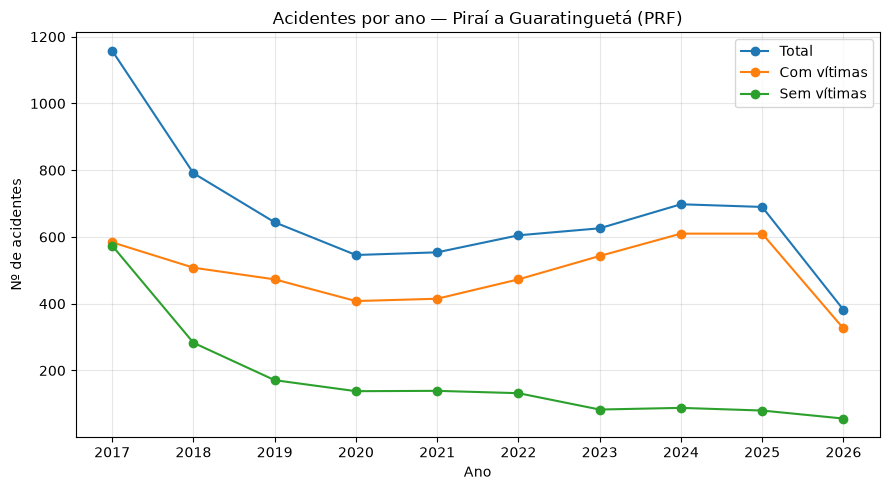

In [117]:
import matplotlib.pyplot as plt   # biblioteca de gráficos

# Gráfico com TRÊS linhas no mesmo eixo: total, com vítimas e sem vítimas.
plt.figure(figsize=(9, 5))                            # tamanho (largura, altura em polegadas)

# Cada plt.plot desenha uma linha. 'label' é o nome que aparece na legenda.
plt.plot(panorama.index, panorama["Total"],       marker="o", label="Total")
plt.plot(panorama.index, panorama["Com vítimas"], marker="o", label="Com vítimas")
plt.plot(panorama.index, panorama["Sem vítimas"], marker="o", label="Sem vítimas")

plt.title("Acidentes por ano — Piraí a Guaratinguetá (PRF)")
plt.xlabel("Ano")
plt.ylabel("Nº de acidentes")
plt.xticks(panorama.index)          # mostra todos os anos no eixo x
plt.legend()                        # mostra a legenda (qual cor é qual linha)
plt.grid(True, alpha=0.3)           # grade leve pra facilitar a leitura
plt.tight_layout()                  # ajusta as margens

# Salva a figura na pasta de resultados do projeto.
plt.savefig("/home/nathgobira/Documentos/Acidentes-Dutra/data/processed/regiao_acidentes_por_ano.png", dpi=120)
plt.show()

# O que observar:
# - "Sem vítimas" despenca ao longo dos anos -> é a mudança de registro da PRF.
# - "Total" cai junto, puxado por essa queda -> parece melhora, mas é artificial.
# - "Com vítimas" faz um vale em 2020 (pandemia) e se recupera -> o movimento real.
# - 2026 é parcial, então as três linhas caem no último ponto só porque o ano não acabou.

## Microtarefa 2 — composição de gravidade

Dentro dos acidentes **com vítimas**, qual a gravidade do dano às pessoas?

Aqui a unidade **muda**: em vez de contar *acidentes*, contamos **pessoas** feridas
ou mortas — as colunas `mortos`, `feridos_graves` e `feridos_leves` da PRF. Um mesmo
acidente pode ter várias vítimas de níveis diferentes, então somamos as pessoas de
cada gravidade por ano.

In [118]:
# Soma de vítimas por gravidade, por ano.
# ATENÇÃO: aqui contamos PESSOAS, não acidentes (um acidente pode ter várias vítimas).
gravidade = com_vitimas.groupby("ano")[["mortos", "feridos_graves", "feridos_leves"]].sum()

# Renomeia as colunas pra ficar mais legível na tabela e no gráfico.
gravidade.columns = ["Mortos", "Feridos graves", "Feridos leves"]

print(gravidade)
print("\nTotais do período:")
print(gravidade.sum())

      Mortos  Feridos graves  Feridos leves
ano                                        
2017      51             143            713
2018      35             118            568
2019      53             142            502
2020      36             117            441
2021      39             102            421
2022      40             125            481
2023      37             130            614
2024      35             145            720
2025      31             138            709
2026      29              71            387

Totais do período:
Mortos             386
Feridos graves    1231
Feridos leves     5556
dtype: int64


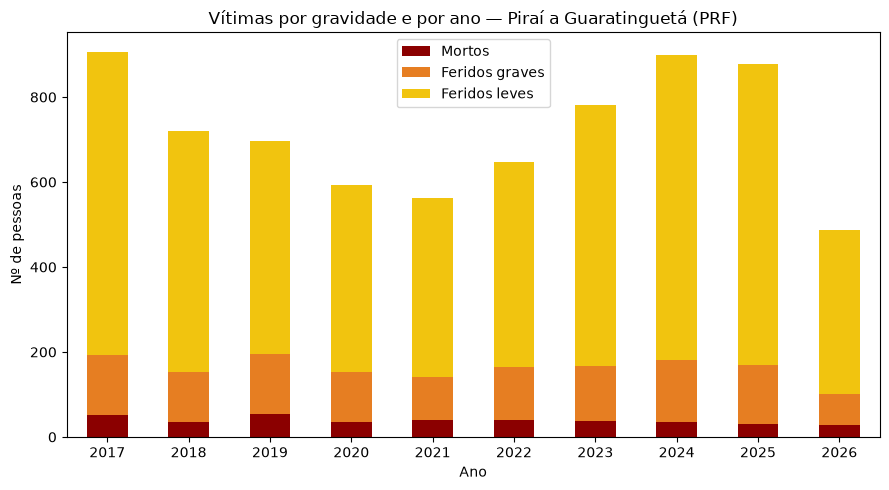

In [119]:
import matplotlib.pyplot as plt

# Barras empilhadas: cada barra é um ano, dividida pelas três gravidades.
# stacked=True empilha as categorias na mesma barra (o topo é o total de vítimas).
ax = gravidade.plot(
    kind="bar", stacked=True, figsize=(9, 5),
    color=["#8B0000", "#E67E22", "#F1C40F"],  # vermelho=mortos, laranja=graves, amarelo=leves
)
ax.set_title("Vítimas por gravidade e por ano — Piraí a Guaratinguetá (PRF)")
ax.set_xlabel("Ano")
ax.set_ylabel("Nº de pessoas")
plt.xticks(rotation=0)          # anos na horizontal (mais legível)
plt.tight_layout()

plt.savefig("/home/nathgobira/Documentos/Acidentes-Dutra/data/processed/regiao_gravidade_por_ano.png", dpi=120)
plt.show()

# O que observar:
# - Feridos leves são a grande maioria das vítimas.
# - Mortos ficam numa faixa estreita (~30-50/ano) e NÃO caíram na pandemia como os
#   leves. Menos acidentes, mas mortalidade parecida -> a investigar melhor.

## Microtarefa 2.1 — sazonalidade: mortos por mês, por ano

Uma linha por ano, mês no eixo x. A linha de **2026** para em julho (é até onde temos
dados), o que deixa fácil enxergar se ela está acima ou abaixo das outras no mesmo
ponto do ano.

In [120]:
# Extrai o mês (posições 6-7 de 'AAAA-MM-DD') e soma mortos por ano e mês.
df_regiao["mes"] = df_regiao["data_inversa"].str[5:7].astype(int)

# Tabela: uma linha por mês (1-12), uma coluna por ano.
# unstack("ano") joga os anos pras colunas. Onde não há dado (2026 depois de julho),
# fica NaN — e o matplotlib simplesmente não desenha, então a linha "para" sozinha.
mortos_ano_mes = df_regiao.groupby(["ano", "mes"])["mortos"].sum().unstack("ano")

print(mortos_ano_mes)

ano  2017  2018  2019  2020  2021  2022  2023  2024  2025  2026
mes                                                            
1     3.0   1.0   3.0   2.0   3.0   2.0   8.0   0.0   3.0   4.0
2     2.0   2.0   7.0   0.0   1.0   4.0   2.0   1.0   3.0   2.0
3     3.0   2.0   3.0   3.0   5.0   3.0   4.0   4.0   1.0   1.0
4     5.0   5.0   6.0   6.0   3.0   1.0   2.0   3.0   3.0   7.0
5     4.0   3.0   8.0   6.0   5.0   4.0   2.0   3.0   1.0   6.0
6     5.0   3.0   4.0   6.0   0.0   3.0   4.0   4.0   3.0   4.0
7     5.0   1.0   0.0   0.0   1.0   5.0   2.0   0.0   4.0   5.0
8     6.0   4.0   2.0   5.0   3.0   1.0   3.0   3.0   3.0   NaN
9     3.0   5.0   1.0   1.0   7.0   8.0   3.0   4.0   1.0   NaN
10    5.0   1.0  11.0   2.0   3.0   6.0   2.0   5.0   3.0   NaN
11    4.0   3.0   6.0   1.0   4.0   1.0   2.0   3.0   4.0   NaN
12    6.0   5.0   2.0   4.0   4.0   2.0   3.0   5.0   2.0   NaN


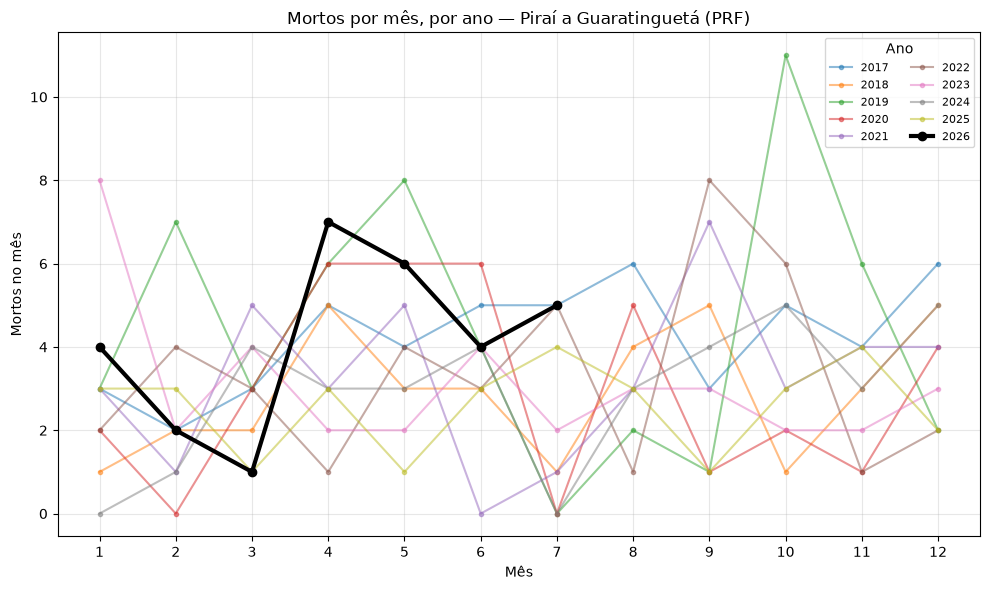

In [121]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Uma linha por ano. 2026 vai destacado (preto e grosso); os demais, finos e claros.
for ano in mortos_ano_mes.columns:
    if ano == 2026:
        plt.plot(mortos_ano_mes.index, mortos_ano_mes[ano],
                 marker="o", linewidth=3, color="black", label="2026", zorder=5)
    else:
        plt.plot(mortos_ano_mes.index, mortos_ano_mes[ano],
                 marker=".", alpha=0.5, label=str(ano))

plt.title("Mortos por mês, por ano — Piraí a Guaratinguetá (PRF)")
plt.xlabel("Mês")
plt.ylabel("Mortos no mês")
plt.xticks(range(1, 13))
plt.legend(title="Ano", ncol=2, fontsize=8)   # 2 colunas pra caber os 10 anos
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("/home/nathgobira/Documentos/Acidentes-Dutra/data/processed/regiao_mortos_por_mes.png", dpi=120)
plt.show()

# Ressalva: são números pequenos (poucas mortes por mês), então a linha serrilha
# bastante de um mês pro outro. O que importa aqui é a POSIÇÃO da linha preta (2026)
# frente às outras nos meses de janeiro a julho.

## Microtarefa 3 — causa dos acidentes (2021–2026)

Aqui a janela muda de propósito: **só 2021 em diante**. A PRF trocou a lista de causas
entre 2020 e 2021 (as categorias antigas e amplas — tipo "Falta de Atenção à Condução"
— viraram várias específicas). Misturar os dois períodos inventaria um ranking falso,
então a análise de causa fica só na taxonomia nova, que é estável.

Base: acidentes **com vítimas**, de 2021 a 2026.

In [122]:
# Filtra a base de causa: acidentes com vítimas, só de 2021 em diante
# (por causa da mudança de taxonomia de causa na PRF entre 2020 e 2021).
causas_base = com_vitimas[com_vitimas["ano"] >= 2021]

# Conta acidentes por causa, do maior pro menor.
causas = causas_base["causa_acidente"].value_counts()

print("Nº de causas distintas:", causas.shape[0])
print("Total de acidentes na base de causa:", len(causas_base))
print("\nTop 15 causas:")
print(causas.head(15))

Nº de causas distintas: 64
Total de acidentes na base de causa: 2977

Top 15 causas:
causa_acidente
Reação tardia ou ineficiente do condutor                     573
Ausência de reação do condutor                               516
Velocidade Incompatível                                      211
Condutor deixou de manter distância do veículo da frente     159
Condutor Dormindo                                            148
Manobra de mudança de faixa                                  145
Demais falhas mecânicas ou elétricas                         128
Avarias e/ou desgaste excessivo no pneu                      108
Chuva                                                         81
Acessar a via sem observar a presença dos outros veículos     79
Acumulo de água sobre o pavimento                             77
Pedestre andava na pista                                      54
Pista Escorregadia                                            54
Ingestão de álcool pelo condutor                       

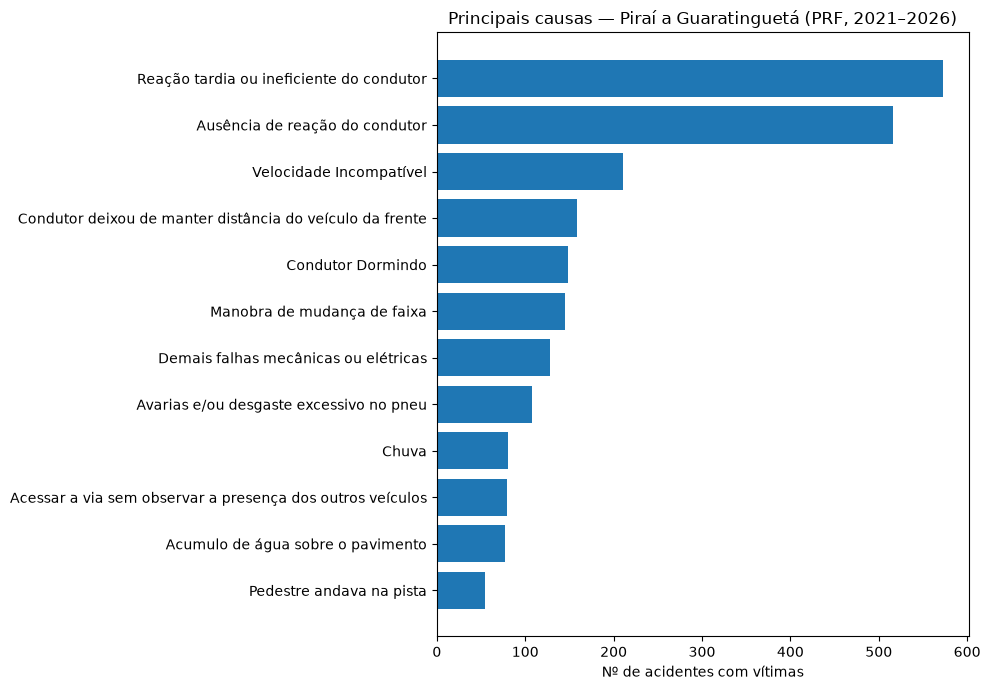

In [123]:
import matplotlib.pyplot as plt

# As 12 causas mais frequentes (nomes longos -> barras horizontais cabem melhor).
top = causas.head(12)

plt.figure(figsize=(10, 7))
plt.barh(top.index, top.values)
plt.gca().invert_yaxis()          # coloca a maior no topo
plt.xlabel("Nº de acidentes com vítimas")
plt.title("Principais causas — Piraí a Guaratinguetá (PRF, 2021–2026)")
plt.tight_layout()

plt.savefig("/home/nathgobira/Documentos/Acidentes-Dutra/data/processed/regiao_causa.png", dpi=120)
plt.show()

# O que observar:
# - As duas primeiras ("Reação tardia" + "Ausência de reação") são as duas faces do
#   mesmo problema: erro de atenção/reação do condutor. Juntas, dominam com folga.
# - "Velocidade Incompatível" e "não manter distância" reforçam o fator humano.
# - Fatores de via/clima aparecem depois (Chuva, Acúmulo de água, Pista escorregadia).

## Microtarefa 3.1 — causas agrupadas (humana / veículo / clima / via)

As 64 causas são muitas pra tirar conclusão. Agrupamos em categorias amplas.

As três que interessavam (humana, veículo, clima) não cobrem tudo, então há uma quarta:
**via/ambiente** (buraco, sinalização, animal, objeto na pista, curva). As listas abaixo
são **editáveis** — se você discordar de algum enquadramento, é só mover a causa de lista.

Casos de fronteira que decidi assim (e dá pra mudar): "Acúmulo de água" → clima;
"Pista escorregadia" → via; "Carga excessiva" → humana; causas de pedestre → humana.

In [124]:
# Listas de classificação (editáveis). Tudo que NÃO cair nelas é considerado "Humana".
causas_veiculo = [
    "Demais falhas mecânicas ou elétricas", "Avarias e/ou desgaste excessivo no pneu",
    "Problema com o freio", "Problema na suspensão", "Faróis desregulados",
]
causas_clima = [
    "Chuva", "Acumulo de água sobre o pavimento", "Neblina", "Fumaça",
]
causas_via = [
    "Pista Escorregadia", "Acumulo de óleo sobre o pavimento",
    "Acumulo de areia ou detritos sobre o pavimento", "Ausência de sinalização",
    "Deficiência do Sistema de Iluminação/Sinalização", "Iluminação deficiente",
    "Pista esburacada", "Obras na pista", "Falta de acostamento",
    "Sinalização mal posicionada", "Obstrução na via", "Demais falhas na via",
    "Curva acentuada", "Objeto estático sobre o leito carroçável", "Animais na Pista",
    "Restrição de visibilidade em curvas horizontais",
    "Restrição de visibilidade em curvas verticais",
    "Falta de elemento de contenção que evite a saída do leito carroçável",
    "Afundamento ou ondulação no pavimento", "Acostamento em desnível", "Desvio temporário",
]

# Função que decide o grupo de cada causa.
def classifica_causa(c):
    if c in causas_veiculo: return "Veículo"
    if c in causas_clima:   return "Clima"
    if c in causas_via:     return "Via/ambiente"
    return "Humana"   # o que sobra é comportamento de condutor ou pedestre

# .copy() evita um aviso do pandas ao criar coluna num recorte (SettingWithCopy).
causas_base = causas_base.copy()
causas_base["grupo"] = causas_base["causa_acidente"].apply(classifica_causa)

# Monta a tabela resumo: contagem e porcentagem por grupo.
tabela = causas_base["grupo"].value_counts().rename("acidentes").to_frame()
tabela["%"] = (100 * tabela["acidentes"] / tabela["acidentes"].sum()).round(1)
tabela.loc["TOTAL"] = [tabela["acidentes"].sum(), 100.0]   # linha de total

print(tabela)

              acidentes      %
grupo                         
Humana           2265.0   76.1
Via/ambiente      284.0    9.5
Veículo           261.0    8.8
Clima             167.0    5.6
TOTAL            2977.0  100.0


## Microtarefa 4 — clima

Duas perguntas diferentes, que **não** se respondem com o mesmo número:

1. **Em que clima acontecem os acidentes?** (distribuição) — cuidado: a maioria vai dar
   "Céu Claro", mas isso é porque a maior parte do *tempo* é céu claro (exposição), não
   porque céu claro seja perigoso. Sem saber quantas horas chove vs faz sol, a
   distribuição bruta **não mede risco**.
2. **Dado que houve acidente, ele é mais grave em qual clima?** (letalidade) — essa a PRF
   responde bem, porque é condicional ao acidente já ter acontecido. Medimos
   **mortos por 100 acidentes**.

Base: acidentes com vítimas, 2017–2026 (o clima não teve quebra de taxonomia).

In [125]:
# Agrupa por clima: nº de acidentes e nº de mortos.
# .agg permite criar várias colunas de uma vez, dando nome a cada uma.
clima = com_vitimas.groupby("condicao_metereologica").agg(
    acidentes=("classificacao_acidente", "size"),  # conta linhas do grupo
    mortos=("mortos", "sum"),                       # soma os mortos do grupo
).sort_values("acidentes", ascending=False)

# Letalidade: mortos por 100 acidentes. Isso controla pelo tamanho de cada grupo,
# então responde "quão grave", e não "quão frequente".
clima["mortos_por_100"] = (100 * clima["mortos"] / clima["acidentes"]).round(1)

print(clima)

                        acidentes  mortos  mortos_por_100
condicao_metereologica                                   
Céu Claro                    2464     212             8.6
Nublado                      1074      94             8.8
Chuva                         778      42             5.4
Sol                           372      15             4.0
Garoa/Chuvisco                164      10             6.1
Nevoeiro/Neblina               69       9            13.0
Ignorado                       24       3            12.5
Vento                           5       1            20.0


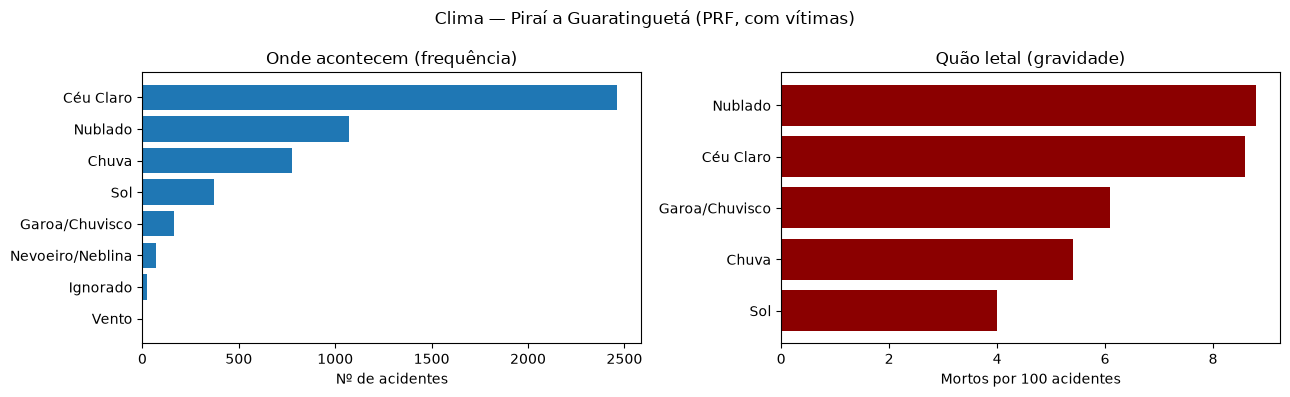

In [126]:
import matplotlib.pyplot as plt

# Dois gráficos lado a lado: distribuição (esquerda) e letalidade (direita).
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Esquerda: quantos acidentes em cada clima (frequência = exposição, NÃO risco).
ax1.barh(clima.index, clima["acidentes"])
ax1.invert_yaxis()
ax1.set_xlabel("Nº de acidentes")
ax1.set_title("Onde acontecem (frequência)")

# Direita: letalidade, só nas categorias com amostra razoável (>=100 acidentes),
# senão o "mortos por 100" fica instável (poucos casos oscilam muito).
clima_conf = clima[clima["acidentes"] >= 100].sort_values("mortos_por_100", ascending=False)
ax2.barh(clima_conf.index, clima_conf["mortos_por_100"], color="#8B0000")
ax2.invert_yaxis()
ax2.set_xlabel("Mortos por 100 acidentes")
ax2.set_title("Quão letal (gravidade)")

fig.suptitle("Clima — Piraí a Guaratinguetá (PRF, com vítimas)")
plt.tight_layout()
plt.savefig("/home/nathgobira/Documentos/Acidentes-Dutra/data/processed/regiao_clima.png", dpi=120)
plt.show()

# O que observar (contra-intuitivo):
# - À esquerda, "Céu Claro" domina -> mas é exposição (faz sol na maior parte do tempo).
# - À direita, CHUVA é MENOS letal (5.4) que céu claro (8.6). Na chuva se dirige devagar;
#   no seco, mais velocidade -> mais morte. Reforça: o vilão é velocidade/comportamento.

## Microtarefa 4.1 — associação clima × gravidade (Cramér's V)

Clima e gravidade são **categóricas**, então a "correlação" certa aqui é o **Cramér's V**
(não a de Pearson, que é pra números). Escala: 0 = nenhuma associação, ~0,1 fraca,
~0,3 moderada, ~0,5 forte.

Agora com `scipy`: a função `chi2_contingency` faz o teste e dá o **p-valor** de bônus.
O Cramér's V ela não devolve pronto — calculamos a partir do qui-quadrado.

In [127]:
from scipy.stats import chi2_contingency
import numpy as np

# 1) Tabela de contingência: clima x classificação (fatal vs ferida).
#    Só climas com amostra razoável (>=100), senão o teste fica frágil.
climas_grandes = com_vitimas["condicao_metereologica"].value_counts()
climas_grandes = climas_grandes[climas_grandes >= 100].index
sub = com_vitimas[com_vitimas["condicao_metereologica"].isin(climas_grandes)]
tab = pd.crosstab(sub["condicao_metereologica"], sub["classificacao_acidente"])
print(tab)

# 2) chi2_contingency faz o teste de uma vez. Devolve, nesta ordem:
#    qui-quadrado, p-valor, graus de liberdade e a tabela esperada (sob independência).
chi2, p, dof, esperado = chi2_contingency(tab)

# 3) Cramér's V o scipy NAO devolve pronto: sqrt(chi2 / (n * (menor_dim - 1))).
n = tab.values.sum()
k = min(tab.shape)
cramer_v = np.sqrt(chi2 / (n * (k - 1)))

print(f"\nqui-quadrado = {chi2:.2f}")
print(f"p-valor      = {p:.4f}")
print(f"Cramer's V   = {cramer_v:.3f}")
print("\nLeitura: o p-valor eh pequeno (da 'significativo'), MAS o Cramer's V ~ 0.06")
print("mostra que a associacao é desprezivel. Com amostra grande o p quase sempre da")
print("significativo; por isso o que importa aqui eh o tamanho do efeito (o V).")

classificacao_acidente  Com Vítimas Fatais  Com Vítimas Feridas
condicao_metereologica                                         
Chuva                                   38                  740
Céu Claro                              196                 2268
Garoa/Chuvisco                          10                  154
Nublado                                 90                  984
Sol                                     14                  358

qui-quadrado = 17.51
p-valor      = 0.0015
Cramer's V   = 0.060

Leitura: o p-valor eh pequeno (da 'significativo'), MAS o Cramer's V ~ 0.06
mostra que a associacao é desprezivel. Com amostra grande o p quase sempre da
significativo; por isso o que importa aqui eh o tamanho do efeito (o V).


## Microtarefa 5 — quando acontecem (dia, período e o cruzamento)

Base: acidentes com vítimas, 2017–2026 (dia da semana e período são estáveis em todos
os anos). Três visões: por dia da semana, por período do dia (`fase_dia`) e o cruzamento
dos dois.

dia_semana
segunda-feira    679
terça-feira      620
quarta-feira     628
quinta-feira     667
sexta-feira      705
sábado           808
domingo          843
Name: count, dtype: int64


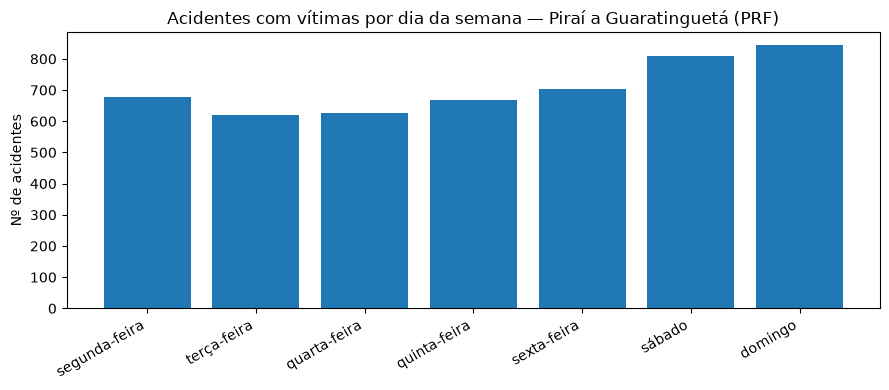

In [128]:
import matplotlib.pyplot as plt

# Ordem correta dos dias (senão o pandas ordena em ordem alfabética).
ordem_dia = ["segunda-feira","terça-feira","quarta-feira","quinta-feira","sexta-feira","sábado","domingo"]

por_dia = com_vitimas["dia_semana"].value_counts().reindex(ordem_dia)
print(por_dia)

plt.figure(figsize=(9, 4))
plt.bar(por_dia.index, por_dia.values)
plt.title("Acidentes com vítimas por dia da semana — Piraí a Guaratinguetá (PRF)")
plt.ylabel("Nº de acidentes")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("/home/nathgobira/Documentos/Acidentes-Dutra/data/processed/regiao_dia_semana.png", dpi=120)
plt.show()
# Fim de semana (sábado/domingo) e sexta concentram mais; meio de semana é o vale.

fase_dia
Amanhecer       328
Pleno dia      2500
Anoitecer       247
Plena Noite    1875
Name: count, dtype: int64


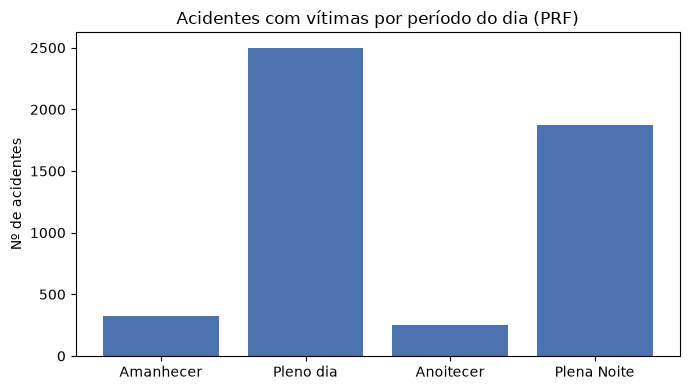

In [129]:
# Ordem dos períodos seguindo o ciclo do dia.
ordem_fase = ["Amanhecer", "Pleno dia", "Anoitecer", "Plena Noite"]

por_fase = com_vitimas["fase_dia"].value_counts().reindex(ordem_fase)
print(por_fase)

plt.figure(figsize=(7, 4))
plt.bar(por_fase.index, por_fase.values, color="#4C72B0")
plt.title("Acidentes com vítimas por período do dia (PRF)")
plt.ylabel("Nº de acidentes")
plt.tight_layout()
plt.savefig("/home/nathgobira/Documentos/Acidentes-Dutra/data/processed/regiao_fase_dia.png", dpi=120)
plt.show()
# Pleno dia e plena noite dominam; amanhecer/anoitecer sao curtos (poucas horas).

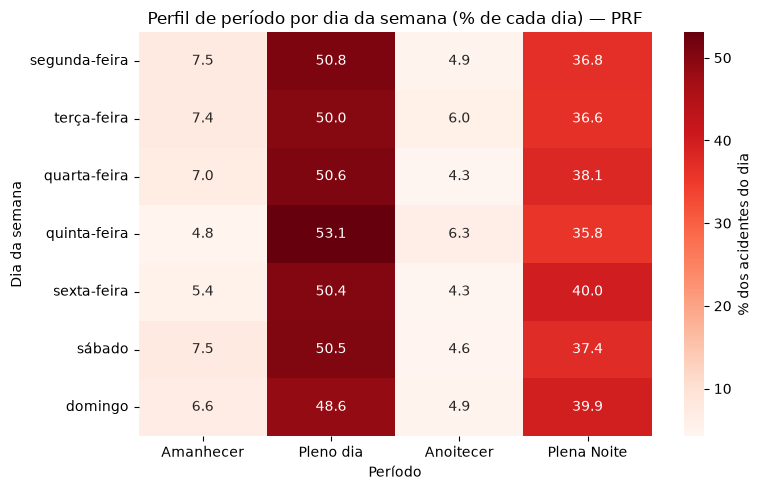

In [130]:
import seaborn as sns

# Cruzamento dia x período. Normalizamos por LINHA (% dentro de cada dia) para comparar
# o PERFIL de cada dia sem o volume total mascarar a leitura.
cruz = pd.crosstab(com_vitimas["dia_semana"], com_vitimas["fase_dia"]).reindex(index=ordem_dia, columns=ordem_fase)
perfil = 100 * cruz.div(cruz.sum(axis=1), axis=0)   # cada linha soma 100%

plt.figure(figsize=(8, 5))
sns.heatmap(perfil, annot=True, fmt=".1f", cmap="Reds", cbar_kws={"label": "% dos acidentes do dia"})
plt.title("Perfil de período por dia da semana (% de cada dia) — PRF")
plt.xlabel("Período"); plt.ylabel("Dia da semana")
plt.tight_layout()
plt.savefig("/home/nathgobira/Documentos/Acidentes-Dutra/data/processed/regiao_dia_x_fase.png", dpi=120)
plt.show()
# Linhas quase iguais entre si -> o perfil de horario NAO muda com o dia da semana.

## Microtarefa 6 — uso do solo (urbano x rural) e a hipótese do morador

`uso_solo` = "Sim" (urbano) ou "Não" (rural). Base: com vítimas, 2017–2026 (estável).

A hipótese: em trecho urbano, onde moradores cruzam a via, deve haver mais **atropelamento
de pedestre** — que é o tipo de acidente que mais mata. Vamos testar isso, não só a
frequência bruta urbano x rural.

In [131]:
# 1) Frequência e letalidade por uso do solo.
uso = com_vitimas.groupby("uso_solo").agg(
    acidentes=("classificacao_acidente", "size"),
    mortos=("mortos", "sum"),
)
uso["mortos_por_100"] = (100 * uso["mortos"] / uso["acidentes"]).round(1)
uso = uso.rename(index={"Sim": "Urbano", "Não": "Rural"})
print(uso)
# Letalidade geral quase igual (7.7 x 7.9) -> a diferença NAO aparece no numero bruto.

          acidentes  mortos  mortos_por_100
uso_solo                                   
Rural          3464     272             7.9
Urbano         1486     114             7.7


% de acidentes que são atropelamento de pedestre:
uso_solo
Rural     5.8
Urbano    9.6
Name: eh_atropelamento, dtype: float64


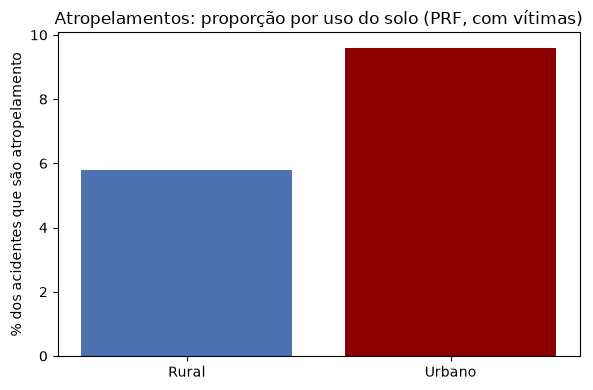

In [132]:
import matplotlib.pyplot as plt

# 2) O teste da hipótese: % de atropelamentos em cada uso do solo.
# Cria uma coluna booleana e usa .mean() (média de True/False = proporção).
com_vitimas = com_vitimas.copy()   # evita aviso ao criar coluna num recorte
com_vitimas["eh_atropelamento"] = com_vitimas["tipo_acidente"] == "Atropelamento de Pedestre"

pct = com_vitimas.groupby("uso_solo")["eh_atropelamento"].mean().mul(100).round(1)
pct = pct.rename(index={"Sim": "Urbano", "Não": "Rural"})
print("% de acidentes que são atropelamento de pedestre:")
print(pct)

plt.figure(figsize=(6, 4))
plt.bar(pct.index, pct.values, color=["#4C72B0", "#8B0000"])
plt.title("Atropelamentos: proporção por uso do solo (PRF, com vítimas)")
plt.ylabel("% dos acidentes que são atropelamento")
plt.tight_layout()
plt.savefig("/home/nathgobira/Documentos/Acidentes-Dutra/data/processed/regiao_atropelamento_uso_solo.png", dpi=120)
plt.show()
# Urbano ~9.6% x rural ~5.8% -> no urbano o pedestre entra muito mais na conta.

               acidentes  mortos  mortos_por_100
grupo_tipo                                      
Atropelamento        345     150            43.5
Outros tipos        4605     236             5.1

Atropelamentos: 7% dos acidentes, mas 39% de TODAS as mortes.


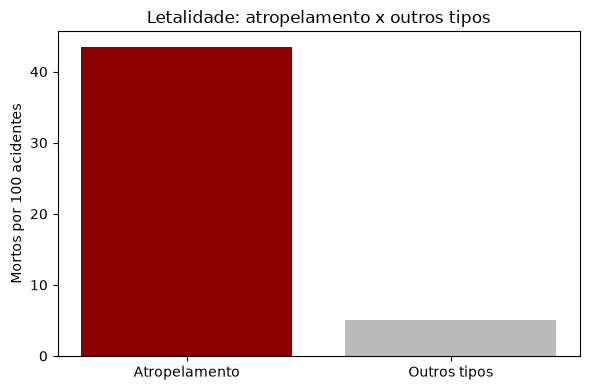

In [133]:
# 3) Por que atropelamento importa tanto: a letalidade.
com_vitimas["grupo_tipo"] = com_vitimas["eh_atropelamento"].map({True: "Atropelamento", False: "Outros tipos"})
let = com_vitimas.groupby("grupo_tipo").agg(
    acidentes=("classificacao_acidente", "size"),
    mortos=("mortos", "sum"),
)
let["mortos_por_100"] = (100 * let["mortos"] / let["acidentes"]).round(1)
print(let)

# Fatia das mortes e dos acidentes que vem de atropelamento.
pct_mortes = 100 * com_vitimas.loc[com_vitimas["eh_atropelamento"], "mortos"].sum() / com_vitimas["mortos"].sum()
pct_acid   = 100 * com_vitimas["eh_atropelamento"].mean()
print(f"\nAtropelamentos: {pct_acid:.0f}% dos acidentes, mas {pct_mortes:.0f}% de TODAS as mortes.")

plt.figure(figsize=(6, 4))
plt.bar(let.index, let["mortos_por_100"], color=["#8B0000", "#BBBBBB"])
plt.title("Letalidade: atropelamento x outros tipos")
plt.ylabel("Mortos por 100 acidentes")
plt.tight_layout()
plt.savefig("/home/nathgobira/Documentos/Acidentes-Dutra/data/processed/regiao_letalidade_atropelamento.png", dpi=120)
plt.show()

## Microtarefa 7 — pontos críticos por quilômetro

Onde, na estrada, os acidentes concentram? **Atenção: o km zera na divisa RJ/SP**, então
sempre agrupamos por **UF + km** (o mesmo número de km existe nos dois estados). Trazemos
também o município de cada ponto. Base: com vítimas, 2017–2026.

In [134]:
cv = com_vitimas.copy()
cv["km_int"] = cv["km"].astype(float).round().astype(int)   # agrupa por km inteiro

# Para cada (uf, km): nº de acidentes, mortos, e o município mais comum do ponto.
# O lambda pega a moda (valor mais frequente) do município naquele km.
hotspots = cv.groupby(["uf", "km_int"]).agg(
    acidentes=("classificacao_acidente", "size"),
    mortos=("mortos", "sum"),
    municipio=("municipio", lambda s: s.mode().iat[0]),
).reset_index().sort_values("acidentes", ascending=False)

print("Top 15 km com mais acidentes com vítimas:")
print(hotspots.head(15).to_string(index=False))

Top 15 km com mais acidentes com vítimas:
uf  km_int  acidentes  mortos          municipio
SP      65        101       6      GUARATINGUETA
SP      60         76       7      GUARATINGUETA
SP      53         74       1             LORENA
SP      51         64       5             LORENA
RJ     311         62       7            RESENDE
SP      58         59       4      GUARATINGUETA
SP      52         56       2             LORENA
RJ     305         55       3            RESENDE
RJ     228         55       1              PIRAI
SP      56         55       8             LORENA
SP      34         53       2 CACHOEIRA PAULISTA
SP      64         52       3      GUARATINGUETA
RJ     279         48       5        BARRA MANSA
RJ     269         48       6        BARRA MANSA
RJ     275         48       0        BARRA MANSA


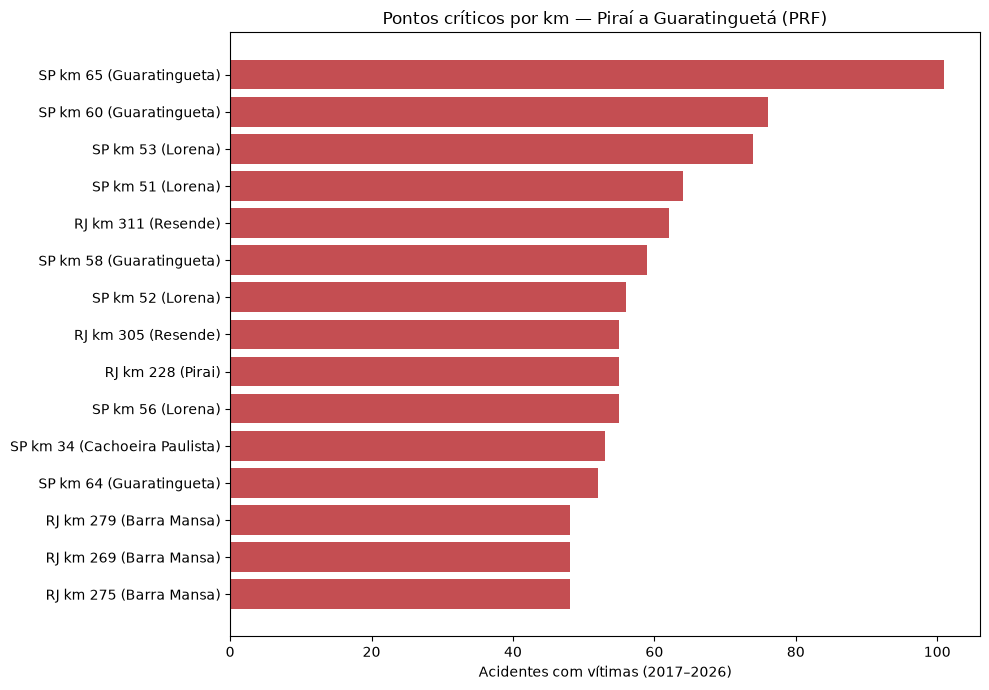

In [135]:
import matplotlib.pyplot as plt

# Rótulo legível: "SP km 65 (Guaratingueta)".
top = hotspots.head(15).copy()
top["rotulo"] = top["uf"] + " km " + top["km_int"].astype(str) + " (" + top["municipio"].str.title() + ")"

plt.figure(figsize=(10, 7))
plt.barh(top["rotulo"], top["acidentes"], color="#C44E52")
plt.gca().invert_yaxis()          # o maior no topo
plt.xlabel("Acidentes com vítimas (2017–2026)")
plt.title("Pontos críticos por km — Piraí a Guaratinguetá (PRF)")
plt.tight_layout()
plt.savefig("/home/nathgobira/Documentos/Acidentes-Dutra/data/processed/regiao_hotspots_km.png", dpi=120)
plt.show()
# Clusters: Guaratingueta (58-65), Lorena (51-56), Resende (305-311), Barra Mansa (269-279).

## Microtarefa 8 — mapa de pontos críticos

Usa `latitude`/`longitude` da PRF (que a ANTT não tem) pra pôr os pontos críticos num
mapa de verdade. Precisa do `folium`: `conda install -c conda-forge folium`.

Cada círculo é um km da estrada; o tamanho cresce com o nº de acidentes. Clicando, abre
km, município, acidentes e mortos. O mapa é salvo como HTML interativo.

In [136]:
import folium
import pandas as pd

# 1) Coordenadas vêm como texto com vírgula decimal -> converte pra número.
cv = com_vitimas.copy()
cv["latitude"]  = pd.to_numeric(cv["latitude"].astype(str).str.replace(",", ".", regex=False), errors="coerce")
cv["longitude"] = pd.to_numeric(cv["longitude"].astype(str).str.replace(",", ".", regex=False), errors="coerce")
cv["km_int"] = cv["km"].astype(float).round().astype(int)

# 2) Agrega por (uf, km): posição média e totais do ponto.
pontos = cv.groupby(["uf", "km_int"]).agg(
    lat=("latitude", "mean"),
    lon=("longitude", "mean"),
    acidentes=("classificacao_acidente", "size"),
    mortos=("mortos", "sum"),
    municipio=("municipio", lambda s: s.mode().iat[0]),
).reset_index()

# 3) Cria o mapa centrado no meio do recorte.
m = folium.Map(location=[pontos["lat"].mean(), pontos["lon"].mean()], zoom_start=10, tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}",
            attr="Tiles © Esri")

# 4) Um círculo por km. Raio cresce com os acidentes (raiz quadrada, pra não estourar).
for _, r in pontos.iterrows():
    folium.CircleMarker(
        location=[r["lat"], r["lon"]],
        radius=3 + r["acidentes"]**0.5,
        color="crimson", fill=True, fill_opacity=0.5,
        popup=f"{r['uf']} km {r['km_int']} ({r['municipio'].title()})<br>{r['acidentes']} acidentes, {r['mortos']} mortos",
    ).add_to(m)

# 5) Salva como HTML interativo (abre no navegador).
saida = "/home/nathgobira/Documentos/Acidentes-Dutra/data/processed/regiao_mapa.html"
m.save(saida)
print("Mapa salvo em:", saida)
m   # no Jupyter, esta última linha mostra o mapa aqui embaixo

Mapa salvo em: /home/nathgobira/Documentos/Acidentes-Dutra/data/processed/regiao_mapa.html
